PROJECT TITLE: PREDICTION OF REFERENCE EVAPOTRANSPIRATION WITH MACHINE LEARNING MODELS, Evaluation Mode


In the model development phase three alternative machine learning algorithms were trained with hourly wether data spanning 6 years to predict hourly reference evapotraspiration.
the candiate models were 
        1. Regression Tree Model  
        2. Random Forest Model
        3. XGBoost Model

Based on analysis of model performance on the training and test data sets, the XGBoost model was selected for further consideration.  
Here the stability and generalization capability of XGBoost model is evaluated with 3 sets of completely unseen data. 

DATA: The data set used in this project consists of measured hourly weather data and reference evapotranspiration calculated with the Penman-Monteith equation  
      The data set used in model evaluation are:

      Data set I:    Four years of hourly weather data spanning spanning the period 01-01-2017 to 12-31-2020 
      Data set II:   Four years of hourly weather data spanning spanning the period 01-01-2021 to 12-31-2024
      data set III:  A year and a half of hourly weather data spanning the period 01-01-2025 to 06-27-2026 
      
      Data was obtained from AZMET: Arizona Meteorological Network website (https://azmet.arizona.edu/azmet/14.htm)
      A description of the complete data set is provided in the data acquisition and preparation notebook  
      The feature set used in modeling evapotranspiration consists of: 
      
      1. av_hr_ta:    Hourly average air temperature
      2. av_vap_d:    Hourly average vapor pressure deficit 
      3. tot_sol_eng: Hourly total solar energy flux per square meter 
      4. soil_temp_5: Hourly average soil temperature at 5cm depth from the surface
      5. av_wnd_spd:  Hourly average wind speed 

      and the dependent variable is 
      
      Eto: Reference evapotranspiration calculated with the Penman-Monteith equation

      The data set consists of 52608 rows by 6 columns
      
PERFORMANCE METRICS USED FOR MODEL EVALUATION AND SELECTION:

        1. Regression Coefficient of Determination, R²
        2. Root Mean Squared Error, mse
        3. Mean Absolute Error, mae

In addition, overfitting risk was assessed based on comparison of model's training and test phase performances 

In [29]:

import io                          # a python librray for handling stream-based input and output operations
import os                          # a python module for interacting with the operating system    
import joblib                      # a thrid party open-source package (a specialized tool) tailored for scientific computing and machine learning.
                                   # It provides lightweight pipelining, transparent disk-caching (memoization), and advanced parallel computing capabilities
import pandas as pd
import numpy as np

# ====================================================================================
# 1. Import data, a csv file from the local drive and read it into pandas data frame
# ====================================================================================

input_file_path = r'C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\EvaluationData\Eval_Data_2020\2017_2020_Hourly.csv'
WeatherEt_df = pd.read_csv(input_file_path, header=0, index_col=False)
WeatherEt_df

,av_hr_ta,av_vap_d,av_sol_eng,soil_temp_5,av_wnd_spd,Eto
0,14.7,0.40,0.0,15.2,4.5,0.02
1,14.0,0.23,0.0,14.9,5.2,0.01
2,12.2,0.15,0.0,14.8,3.2,-0.01
3,11.8,0.16,0.0,14.5,3.1,-0.01
4,11.0,0.17,0.0,14.2,4.4,0.00
...,...,...,...,...,...,...
35059,12.2,1.14,0.0,14.3,1.6,0.05
35060,11.8,1.12,0.0,13.7,3.0,0.08
35061,11.3,1.07,0.0,13.2,2.5,0.07
35062,10.7,0.97,0.0,12.8,1.5,0.04


In [30]:
# Check data type of dataframe columns  

WeatherEt_df.dtypes

av_hr_ta       float64
av_vap_d       float64
av_sol_eng     float64
soil_temp_5    float64
av_wnd_spd     float64
Eto            float64
dtype: object

In [31]:
# Check if any of the dataframe columns contain entries with missing values 

WeatherEt_df.isnull().sum()

av_hr_ta       0
av_vap_d       0
av_sol_eng     0
soil_temp_5    0
av_wnd_spd     0
Eto            0
dtype: int64

In [32]:
# Handling missing data: replace NULLs with NaNs in the dataframe, 'WeatherEt_df', delete each row that contain missing values from the dataframe, 
# and reset the row index of the dataframe. Ensure that rows with NULL values are removed from the dataframe

WeatherEt_df = WeatherEt_df.replace('NULL', np.nan)
WeatherEt_df.dropna(inplace=True)
WeatherEt_df.reset_index(drop=True, inplace=True)
WeatherEt_df.isnull().sum()

av_hr_ta       0
av_vap_d       0
av_sol_eng     0
soil_temp_5    0
av_wnd_spd     0
Eto            0
dtype: int64

In [33]:
WeatherEt_df.columns

Index(['av_hr_ta', 'av_vap_d', 'av_sol_eng', 'soil_temp_5', 'av_wnd_spd',
       'Eto'],
      dtype='object')

In [34]:

# Set output directory to match the EVALUATION folder to avoid overwriting training logs
evaluation_dir = os.path.dirname(input_file_path)
model_dir = r'C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\TrainingAndTesting'

# Load the saved model
model_path = os.path.join(model_dir, 'optimized_xgboost_eto.joblib')
print(f"--- Loading Saved XGBoost Model ---")
loaded_rf = joblib.load(model_path)
print("Success! Model loaded and ready for prediction.")

# =====================================================================
# STEP 2: PREPARE YOUR NEW INPUT DATA
# =====================================================================
X_new = WeatherEt_df[['av_hr_ta', 'av_vap_d', 'av_sol_eng', 'soil_temp_5', 'av_wnd_spd']] 

# =====================================================================
# STEP 3: RUN PREDICTION MODE
# =====================================================================
print(f"\n--- Running Predictions ---")
new_predictions = loaded_rf.predict(X_new)

# Combine the predictions into a clean dataframe
predictions_df = pd.DataFrame({
                                    'Predicted_Eto': new_predictions
                             }).round(2)

print("\nFirst 5 Predicted Eto Values (Screen Print):")
print(predictions_df.head())

# =====================================================================
# STEP 4: EXPORT THE RESULTS TO THE CORRECT EVALUATION FOLDER
# =====================================================================
# Saved with a fresh name in the Evaluation directory to avoid caching confusion
output_csv_path = os.path.join(evaluation_dir, 'eval_eto_predictions_output.csv')
WeatherEt_df['Predicted_Eto'] = predictions_df.values
WeatherEt_df.to_csv(output_csv_path, index=False)

print(f"\nPredictions successfully saved to:\n--> {output_csv_path}")
print("Please open this specific file path to verify your numbers match!")
print(len(predictions_df))  

--- Loading Saved XGBoost Model ---
Success! Model loaded and ready for prediction.

--- Running Predictions ---

First 5 Predicted Eto Values (Screen Print):
   Predicted_Eto
0           0.02
1           0.01
2          -0.01
3          -0.01
4           0.00

Predictions successfully saved to:
--> C:\MyFiles_NewComputer\MyDocuments\ModelingEvaporation_with_MLM\RegTreeRandForestXGBoost_Models\Data\EvaluationData\Eval_Data_2020\eval_eto_predictions_output.csv
Please open this specific file path to verify your numbers match!
35064


C:\Users\dawit\AppData\Local\Temp\ipykernel_27140\1073569614.py:29: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_val = max(float(Eto_observed.max()), float(Eto_predicted.max()))
C:\Users\dawit\AppData\Local\Temp\ipykernel_27140\1073569614.py:30: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  min_val = min(float(Eto_observed.min()), float(Eto_predicted.min()))


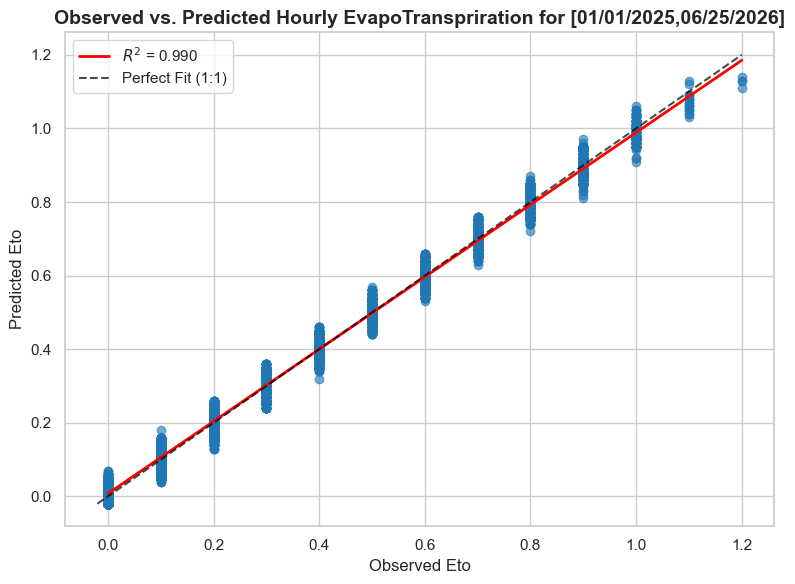

Percent RMSE with respect to the mean observed Eto : 0.3588%
Percent MAE with respect to the mean observed Eto  : 10.3533%


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn library provides the tools for performance metrics used in evaluation of the models 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Generate model predictions (replace 'model' and 'X_eval' with your actual variables)
# For example: y_pred = random_forest_model.predict(X_eval)
# Ensure 'y_pred' matches the length of your observed data
Eto_observed = WeatherEt_df['Eto']
Eto_predicted = predictions_df  # Replace with your actual prediction array or series

# 2. Calculate the R² (Coefficient of Determination)
r2 = r2_score(Eto_observed, Eto_predicted)

# 3. Create the Seaborn scatter plot with a regression line
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# sns.regplot automatically plots the scatter points and fits a regression line
ax = sns.regplot(
                    x = Eto_observed, 
                    y = Eto_predicted, 
                    scatter_kws={'alpha': 0.6, 'color': '#1f77b4'}, 
                    line_kws={'color': 'red', 'linewidth': 2, 'label': f'$R^2$ = {r2:.3f}'}
                )

# 4. Add a 1:1 perfect diagonal reference line (optional, but highly recommended)
max_val = max(float(Eto_observed.max()), float(Eto_predicted.max()))
min_val = min(float(Eto_observed.min()), float(Eto_predicted.min()))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', alpha=0.7, label='Perfect Fit (1:1)')

# 5. Label axes and finalize layout
plt.title('Observed vs. Predicted Hourly EvapoTranspriration for [01/01/2017,06/25/2026]', fontsize=14, fontweight='bold')
plt.xlabel('Observed Eto', fontsize=12)
plt.ylabel('Predicted Eto', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()

plt.savefig(os.path.join(evaluation_dir, 'eto_actual_vs_predicted_xbg.png'), dpi=300)

# 6. Display the plot
plt.show()

av_Eto_observed = np.mean(Eto_observed)
prmse = mean_squared_error(Eto_observed,Eto_predicted)/av_Eto_observed * 100                       # Root mean squared error expessed as percentage of the mean observed reference evapotranspriration - evaluated with Penman-Monteith eq.
pmae = mean_absolute_error(Eto_observed,Eto_predicted)/av_Eto_observed * 100                       # Mean absolute error expressed as percentage of the mean observed reference evapotranspriration
 
print(f"{'Percent RMSE with respect to the mean observed Eto':<20} : {prmse:.4f}%")   
print(f"{'Percent MAE with respect to the mean observed Eto ':<20} : {pmae:.4f}%")   

# Comment:

The total number of data points in the data set is 31994. The regression R^2 between the model predicted and observed Eto is 0.993. 

- In order to provide a measure of the model performance, after accounting for the observed spread about the mean, we have calculated the Percent Root Mean Squared Error (PRMSE) 
  with respect to the mean observed Eto (0.231%) and the Percent Mean Absolute Error (PMAE) with respect to the mean observed Eto (7.063%)
- These results suggest that the XGBoost model provides a good approximation of the observed Eto for the 2021-2024 hourly weather data - which is a completely unseen/new data
- It can be observed that the data points show greater spread about the regression line at regular intervals 0.1mm. This is in part due to differences in significant digits
  between model predicted and observed Eto values 

